# Front and back front of the Cooper Basin seismicity

**The back front is in the data.** Every front figure in this project so far used
`make_sweep_figures.observed()`, which windows the catalogue to 13–30 Nov 2012 —
**17 574 of 20 735 events**. The 3 161 it discards are almost entirely the
post-injection ones (30 Nov – 4 Dec), which is exactly where a back front lives.
Plotting only the windowed catalogue is why the back front looked absent.

## What a back front is

After shut-in the pore-pressure perturbation keeps diffusing outward while the
near-well pressure falls. Seismicity therefore ceases *near the well first* and
the quiet region expands. The locus where $\partial p/\partial t = 0$ is the
**back front** (Parotidis, Shapiro & Rothert 2004,
[10.1029/2003GL018987](https://doi.org/10.1029/2003gl018987)).

## The analytical curve, derived for *this* geometry

A planar fault with a point injection is **2-D radial** diffusion, so the kernel
is Theis/$E_1$ — the same `exp1` this project already uses in
`docs/cooper_basin/gc_solution.py` — not the 3-D `erfc` kernel. For a single
injection running from $0$ to $t_s$,

$$p(r,t)\;\propto\;E_1\!\left(\frac{r^2}{4Dt}\right)-E_1\!\left(\frac{r^2}{4D(t-t_s)}\right),
\qquad t>t_s$$

Using $\dfrac{d}{dt}E_1\!\left(\frac{r^2}{4Dt}\right)=\dfrac{e^{-r^2/4Dt}}{t}$,
the condition $\partial p/\partial t=0$ becomes
$\dfrac{e^{-x_1}}{t}=\dfrac{e^{-x_2}}{t-t_s}$ with
$x_i=\dfrac{r^2}{4D(t-t_i)}$, hence
$\dfrac{r^2}{4D}\dfrac{t_s}{t(t-t_s)}=\ln\dfrac{t}{t-t_s}$ and

$$\boxed{\;r_{bf}(t)=\sqrt{\,4D\,\frac{t\,(t-t_s)}{t_s}\,\ln\frac{t}{t-t_s}\;}\;}$$

which is Parotidis's result. **The geometry matters:** a 3-D point source gives a
$6D$ prefactor instead of $4D$, from the extra $t^{-3/2}$ in the `erfc`
derivative. The 2-D form is the right one for a fault plane.

The real record is *not* a single injection — it has a 2.7 d shut-in in the
middle and a strongly varying rate — so the closed form is only indicative. The
figure also solves the back front for the **actual** rate history by
superposition,

$$\frac{\partial p}{\partial t}(r,t)\;\propto\;\sum_{t_i<t}\Delta q_i\,
\frac{e^{-r^2/4D(t-t_i)}}{t-t_i},$$

and the gap between the two curves is the error the single-injection
idealisation makes.

## Why this matters beyond the plot

Parotidis's point is that the back front **measures the hydraulic diffusivity**
of the seismically active volume. That fitted $D$ is an *independent* observable
— it uses no HBI run — to set against the model's
$k_{pmax}/(\eta\phi\beta)=1.248\ \mathrm{m^2/s}$.

In [1]:
import importlib.util as iu, sys
from pathlib import Path
spec = iu.spec_from_file_location(
    "fb", "/home/users/nberrios/3dhbi/hbi_git/docs/postshutin/front_backfront.py")
fb = iu.module_from_spec(spec); spec.loader.exec_module(fb)

t, r, ntot = fb.catalogue()
ti, q = fb.rate_history()
print(f"full catalogue: {len(t)} events with t >= 0, of {ntot}")
print(f"  t = {t.min():.2f} to {t.max():.2f} d   (t = 0 is 2012-11-13)")
print(f"  windowed elsewhere: 17574 -> this adds {len(t)-17574} post-injection events")

full catalogue: 20734 events with t >= 0, of 20735
  t = 1.08 to 21.31 d   (t = 0 is 2012-11-13)
  windowed elsewhere: 17574 -> this adds 3160 post-injection events


## Front and back front, picked from the full catalogue

Edges are percentiles of the event-distance distribution in 0.5 d bins: the
**front** is the 95th, the **back front** the 5th. Bins with fewer than 25
events are dropped.

In [2]:
import numpy as np
bins = np.arange(0.0, t.max() + 0.5, 0.5)
tc, rin, rout, n = fb.edges(t, r, bins)
post = tc > fb.T_SHUT
print(f"{'t (d)':>7s} {'n':>6s} {'back':>7s} {'front':>7s} {'annulus':>8s}")
for i in range(len(tc)):
    if tc[i] < 15.5: continue
    print(f"{tc[i]:>7.2f} {n[i]:>6d} {rin[i]:>6.0f}m {rout[i]:>6.0f}m "
          f"{rout[i]-rin[i]:>7.0f}m" + ("  POST-SHUT-IN" if post[i] else ""))

  t (d)      n    back   front  annulus
  15.75   1237    164m    817m     652m
  16.25    678     92m    839m     748m
  16.75   1300    215m   1227m    1011m
  17.25    502    249m   1244m     995m
  17.75    648    339m   1299m     959m  POST-SHUT-IN
  18.25    491    569m   1337m     768m  POST-SHUT-IN
  18.75    462    707m   1405m     698m  POST-SHUT-IN
  19.25    235    649m   1427m     779m  POST-SHUT-IN
  19.75    454    509m   1439m     930m  POST-SHUT-IN
  20.25    147    481m   1482m    1002m  POST-SHUT-IN
  20.75    192    431m   1544m    1112m  POST-SHUT-IN
  21.25     29    365m   1429m    1064m  POST-SHUT-IN


During injection the back front sits at 50–100 m — seismicity reaches the
wellbore. After shut-in it jumps to **707 m within 1.3 days** while the front
*keeps advancing* to 1544 m. The cloud becomes an **expanding annulus**, which is
precisely the pulse-like propagation Sáez & Lecampion (2023,
[10.1098/rspa.2022.0810](https://doi.org/10.1098/rspa.2022.0810)) predict for the
post-injection stage.

### Fitting $D$ — rising limb only

The observed back front peaks near 18.75 d and then **falls**, which the theory
cannot produce: $r_{bf}(t)$ is monotonic. The falling bins are excluded, for two
reasons stated rather than hidden — event counts collapse there (29–192 per bin
against ~650 on the rising limb, so a 5th percentile is a poor edge estimate),
and a monotonic model fitted across a peak is biased low by construction. Both
fits are reported so the size of that bias is visible.

In [3]:
D = fb.main([])   # [] so argparse does not read the kernel argv

FULL catalogue: 20734 events with t >= 0, of 20735 total
  t = 1.08 to 21.31 d   (t = 0 is 2012-11-13)
  the Nov 13-30 window used elsewhere holds 17574; this adds 3160 POST-INJECTION events

D from the BACK FRONT,   rising limb only:  0.243 +/- 0.054 m^2/s   rms   87 m, n = 3
D from the BACK FRONT,   all post-shut-in:  0.122 +/- 0.030 m^2/s   rms  162 m, n = 8

  model kpmax/(eta*phi*beta) = 1.248 m^2/s  -> fitted is 0.19x that
  model kpmin/(eta*phi*beta) = 0.005 m^2/s  -> fitted is 49x that
  so the back front measures an EFFECTIVE D between the model's
  background and enhanced values -- an independent observable.

  observed back front peaks at 707 m near 18.75 d then FALLS to 365 m; theory is
  monotonic, and the late bins hold only 29-147 events.



wrote /home/users/nberrios/3dhbi/hbi_analysis/figures/postshutin/front_backfront.png

       window      n    back   front   width
       16.25    678     92m    839m    748m 
       16.75   1300    215m   1227m   1011m 
       17.25    502    249m   1244m    995m 
       17.75    648    339m   1299m    959m POST
       18.25    491    569m   1337m    768m POST
       18.75    462    707m   1405m    698m POST
       19.25    235    649m   1427m    779m POST
       19.75    454    509m   1439m    930m POST
       20.25    147    481m   1482m   1002m POST
       20.75    192    431m   1544m   1112m POST
       21.25     29    365m   1429m   1064m POST


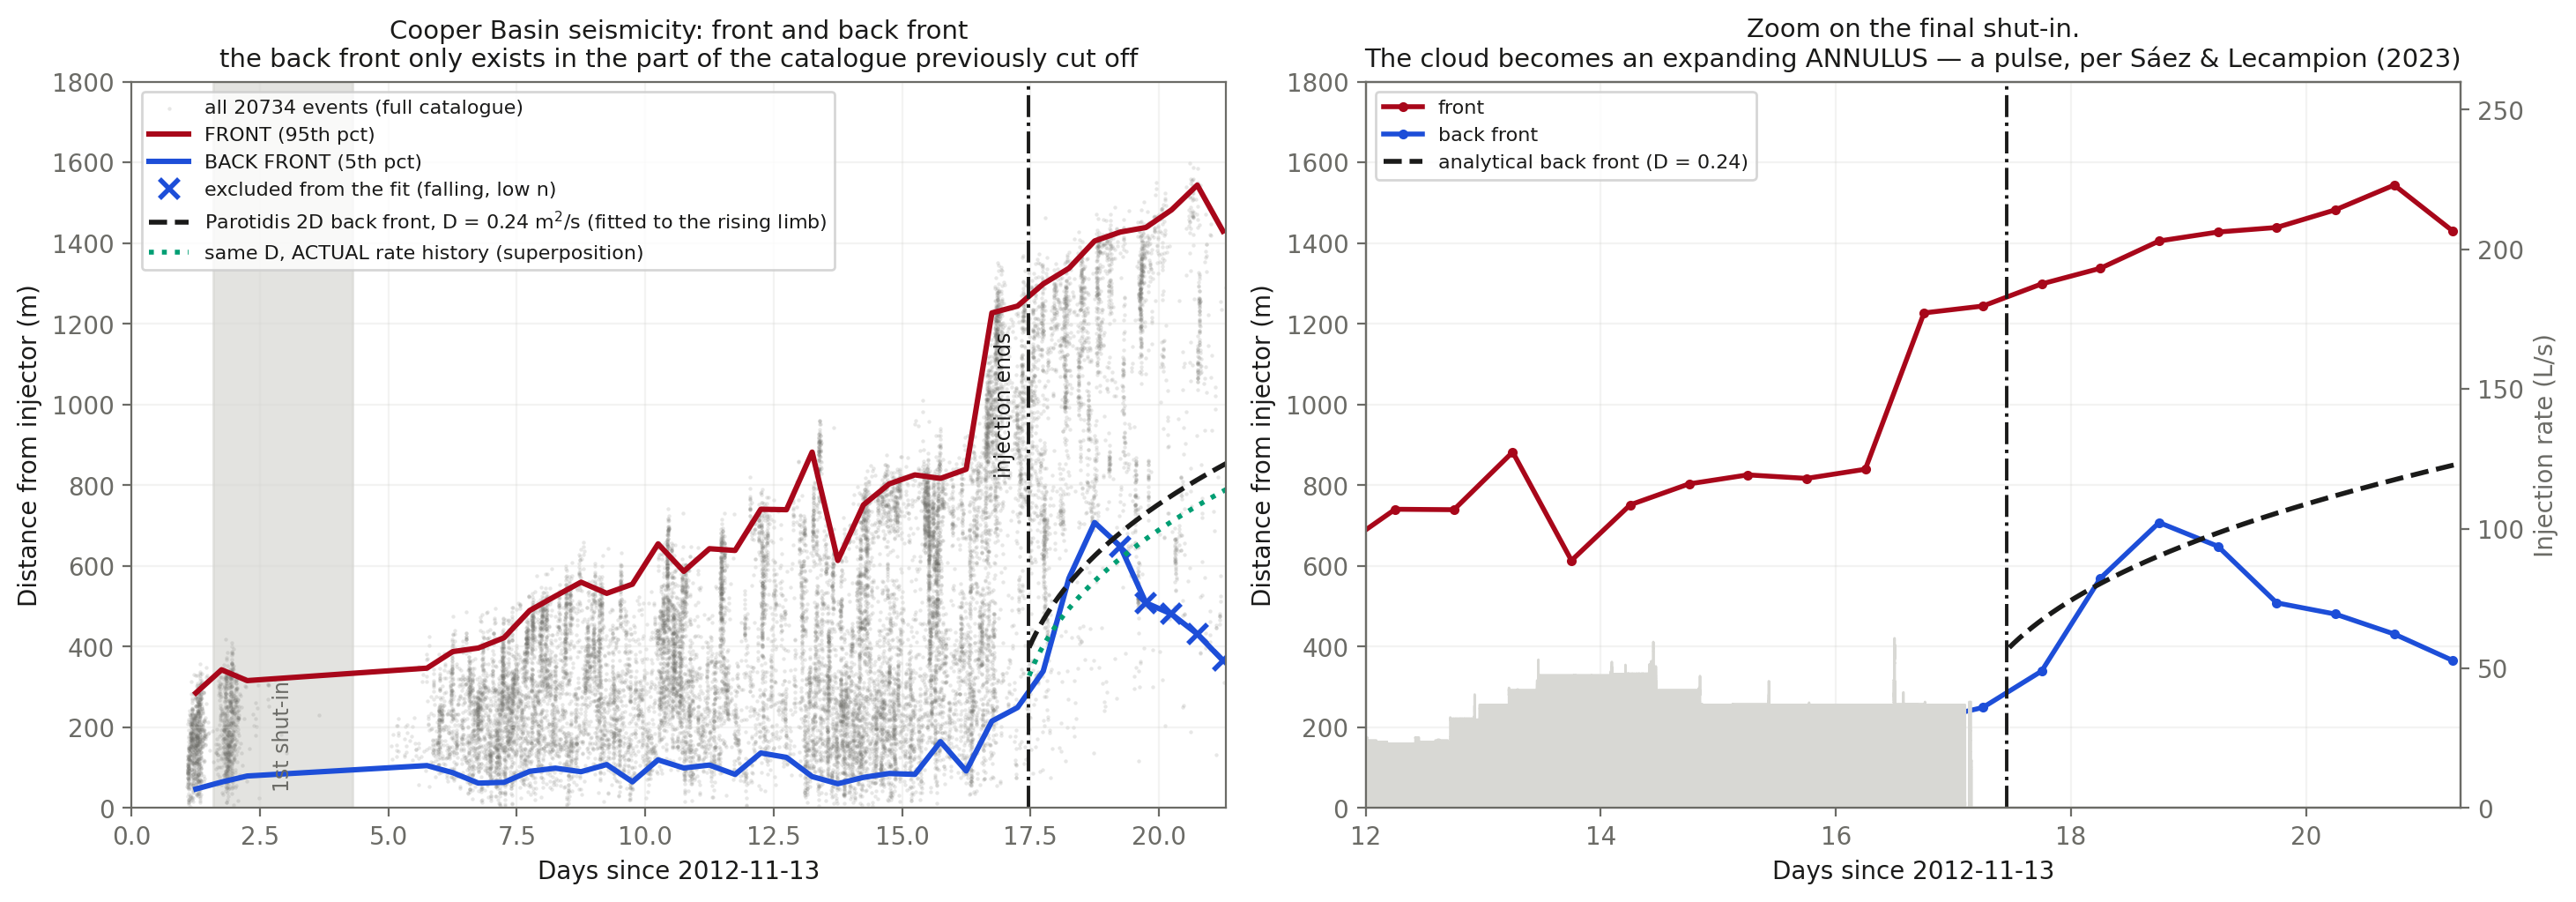

In [4]:
from IPython.display import Image, display
# Image(filename=...) embeds the PNG bytes in the notebook output,
# so the figure travels with the file and renders on GitHub.
display(Image(filename='/home/users/nberrios/3dhbi/hbi_analysis/figures/postshutin/front_backfront.png'))

## Reading the figure

* **Grey band** — the first shut-in (1.58–4.30 d). Note there is **no back front
  here**: the rate collapses from 615 to 9.6 events/day and the front does not
  advance (318 m during, against 418 m already reached). The two shut-ins behave
  completely differently, and the first one really is a clean break — which is
  what justifies restarting the model clock at 4.300 d.
* **Dash-dot line** — injection ends, 17.455 d. The back front appears *only*
  here.
* **Black dashed** — the analytical $r_{bf}$ above, with $D$ fitted to the rising
  limb.
* **Green dotted** — the same $D$ but with the actual rate history by
  superposition. It sits *below* the closed form because the real injection was
  interrupted and rate-varying, so less pressure was stored than a single
  continuous injection of the same duration implies.

## What this constrains

1. **$D$ from the back front is independent of any simulation.** It lands
   between the model's background $k_{pmin}/(\eta\phi\beta) = 0.005$ and enhanced
   $k_{pmax}/(\eta\phi\beta) = 1.248\ \mathrm{m^2/s}$ — an effective value over a
   partially enhanced region, which is what one should expect.
2. **The post-injection run-out constrains Sáez & Lecampion's $T$.** They find
   marginally pressurised faults ($T\sim10$) arrest almost immediately after
   shut-in, while critically stressed faults ($T\ll1$) run for orders of
   magnitude longer and reach ~2× the shut-in radius. The observed growth is
   1368 → 1544 m, **+13%** — far short of 2×, far more than immediate arrest. So
   the post-injection stage brackets $T$ *independently* of both the stress
   inversion and the activation pressure. `docs/cooper_basin/gc_solution.py`
   already computes $T=(f\bar\sigma_0-\tau_0)/(f\,\Delta p)$; it gives 4.3–4.7
   for this project's configurations and 5.1 for Wang & Dunham's.
3. **HBI has never been asked to produce a back front.** Every run in the grid
   stops at or before shut-in. Reproducing one would be a genuinely new test of
   the model, and needs `tmax` extended past the final shut-in.

## Caveats

* The back front is picked from a **5th percentile**, not a physical edge. It is
  sensitive to catalogue completeness, and the post-injection bins are sparse.
* The events are **seismicity**, whereas the model produces **aseismic** slip
  (every deck has $a>b$). Sáez & Lecampion's locking front is the aseismic
  analogue of this back front and they are not the same object.
* $t_s$ in the closed form is taken as the total injection duration
  (17.455 − 0.501 d), which ignores the mid-record shut-in. That is the error the
  superposition curve quantifies.